In [118]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from qutip_qip.operations import (berkeley, cnot, cphase, csign, fredkin,
                                  gate_sequence_product, globalphase, iswap,
                                  molmer_sorensen, phasegate, qrot, rx, ry, rz,
                                  snot, sqrtiswap, sqrtnot, sqrtswap, swap,
                                  swapalpha, toffoli)
from qutip import gates
import simulator_functions
import simulator_class
#reload packages
import importlib
importlib.reload(simulator_functions)
importlib.reload(simulator_class)
from simulator_functions import *
from simulator_class import QCircuit, RandomQCircuit

In [119]:
#State teleportation circuit
q = QCircuit(3)
#Bell state of 1 and 2
q.apply_gate(X_target, 0)  # |1> in qbit 0 instead 
print("Initial state of qubits 0, 1, and 2:", q.state)
q.bell_state(1, 2)
print("Initial state of qubits 1 and 2 (Bell state):", q.state)
q.apply_cnot(0, 1)
q.apply_gate(H_target, 0)
outcome0, prob0 = q.measure(0)
outcome1, prob1 = q.measure(1)
if outcome1 == 1: # if 1 then apply X
    q.apply_gate(X_target, 2)
if outcome0 == 1: # if 1 then apply Z
    q.apply_gate(Z_target, 2)
print("Final state of qubit 2 after teleportation:", q.state)
outcome2, prob2 = q.measure(2)
print("Outcome of measurement on qubit 2:", outcome2)
print("Probabilities of measurement on qubit 2:", prob2)


Initial state of qubits 0, 1, and 2: [[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [1.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]]
Initial state of qubits 1 and 2 (Bell state): [[0.        +0.j]
 [0.        +0.j]
 [0.        +0.j]
 [0.        +0.j]
 [0.70710678+0.j]
 [0.        +0.j]
 [0.        +0.j]
 [0.70710678+0.j]]
Final state of qubit 2 after teleportation: [[0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [0.+0.j]
 [1.+0.j]]
Outcome of measurement on qubit 2: 1
Probabilities of measurement on qubit 2: [np.float64(0.0), np.float64(1.0)]


In [120]:
#Ladder ansatz circuit
size = 3
q = QCircuit(size)
theta = np.pi / 4
for i in range(size):
    q.rotation(theta, 'y', i)
q.apply_cnot(0, 1)
q.apply_cnot(1, 2)
for i in range(3):
    q.rotation(theta, 'y', i)
q.apply_cnot(0, 1)
q.apply_cnot(1, 2)
print(q.state)


[[0.47855339+0.j]
 [0.40533009+0.j]
 [0.375     +0.j]
 [0.1982233 +0.j]
 [0.125     +0.j]
 [0.5517767 +0.j]
 [0.125     +0.j]
 [0.3017767 +0.j]]


In [121]:
from qutip_qip.circuit import QubitCircuit
from qutip_qip.operations import Gate
qc = QubitCircuit(N=3, reverse_states=False)
theta = np.pi / 4
cnot_gate1 = Gate("CNOT", targets=[1], controls=[0])
cnot_gate2 = Gate("CNOT", targets=[2], controls=[1])
ry_gate1 = Gate("RY", targets=[0], arg_value=theta)
ry_gate2 = Gate("RY", targets=[1], arg_value=theta)
ry_gate3 = Gate("RY", targets=[2], arg_value=theta)
qc.add_gate(ry_gate1)
qc.add_gate(ry_gate2)
qc.add_gate(ry_gate3)
qc.add_gate(cnot_gate1)
qc.add_gate(cnot_gate2)
qc.add_gate(ry_gate1)
qc.add_gate(ry_gate2)
qc.add_gate(ry_gate3)
qc.add_gate(cnot_gate1)
qc.add_gate(cnot_gate2)
# qc.draw()
zero_state = qt.tensor(qt.basis(2, 0), qt.basis(2, 0), qt.basis(2, 0))
result_qutip = qc.run(zero_state)
print(result_qutip)


Quantum object: dims=[[2, 2, 2], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[0.47855339]
 [0.40533009]
 [0.375     ]
 [0.1982233 ]
 [0.125     ]
 [0.5517767 ]
 [0.125     ]
 [0.3017767 ]]


In [122]:
import qiskit as qk
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
qck = qk.QuantumCircuit(3)
theta = Parameter('theta')
# theta = np.pi / 4
qck.ry(theta, 0)
qck.ry(theta, 1)
qck.ry(theta, 2)
qck.cx(0,1)
qck.cx(1,2)
qck.ry(theta, 0)
qck.ry(theta, 1)
qck.ry(theta, 2)
qck.cx(0,1)
qck.cx(1,2)
qck.draw()
qck.parameters
bc = qck.assign_parameters({theta: np.pi / 4})
final_state_qiskit = Statevector(bc)
print(final_state_qiskit)
# qck.draw()



Statevector([0.47855339+0.j, 0.125     +0.j, 0.375     +0.j,
             0.125     +0.j, 0.40533009+0.j, 0.5517767 +0.j,
             0.1982233 +0.j, 0.3017767 +0.j],
            dims=(2, 2, 2))


In [123]:
print(q.state )
print(result_qutip.full())
print(final_state_qiskit)


[[0.47855339+0.j]
 [0.40533009+0.j]
 [0.375     +0.j]
 [0.1982233 +0.j]
 [0.125     +0.j]
 [0.5517767 +0.j]
 [0.125     +0.j]
 [0.3017767 +0.j]]
[[0.47855339+0.j]
 [0.40533009+0.j]
 [0.375     +0.j]
 [0.1982233 +0.j]
 [0.125     +0.j]
 [0.5517767 +0.j]
 [0.125     +0.j]
 [0.3017767 +0.j]]
Statevector([0.47855339+0.j, 0.125     +0.j, 0.375     +0.j,
             0.125     +0.j, 0.40533009+0.j, 0.5517767 +0.j,
             0.1982233 +0.j, 0.3017767 +0.j],
            dims=(2, 2, 2))


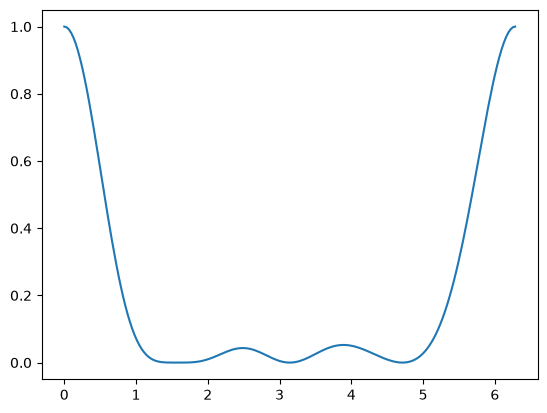

In [124]:
#Ladder ansatz circuit
theta = np.linspace(0, 2 * np.pi, 200)
# theta = np.pi / 4
size = 3
angles = []
statevectors = []
probs = []
for angle in theta:
    q = QCircuit(size)
    for i in range(size):
        q.rotation(angle, 'y', i)
    q.apply_cnot(0, 1)
    q.apply_cnot(1, 2)
    for i in range(size):
        q.rotation(angle, 'y', i)
    q.apply_cnot(0, 1)
    q.apply_cnot(1, 2)
    angles.append(angle)
    statevectors.append(q.state)
    measure = string_to_state("000")
    # |<000|state>|^2
    measure_bra = np.conj(measure.T)
    prob = np.abs(measure_bra @ q.state)**2
    probs.append(prob[0])
fig, ax = plt.subplots()
ax.plot(angles, probs)

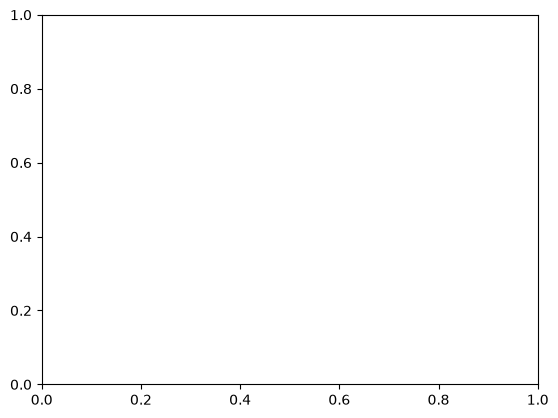

In [125]:
#Ladder ansatz circuit
theta = np.linspace(0, 2 * np.pi, 200)
# theta = np.pi / 4
size = 3
angles = []
statevectors = []
probs = []
for angle in theta:
    q = QCircuit(size)
    q.ladder_ansatz(angle, size)
    angles.append(angle)
    statevectors.append(q.state)
    measure = string_to_state("000")
    # |<000|state>|^2
    measure_bra = np.conj(measure.T)
    prob = np.abs(measure_bra @ q.state)**2
    probs.append(prob[0])
fig, ax = plt.subplots()


In [126]:
size = 3
#Create all possible bitstrings of length size
bitstrings = [format(i, '0' + str(size) + 'b') for i in range(2**size)]
#count the number of 1's in each bitstring
num_ones = [s.count('1') for s in bitstrings]
pm = []
for nums in num_ones:
    term = (-1)**nums
    pm.append(term)


1 to 2 layers
1 to 3 sizes


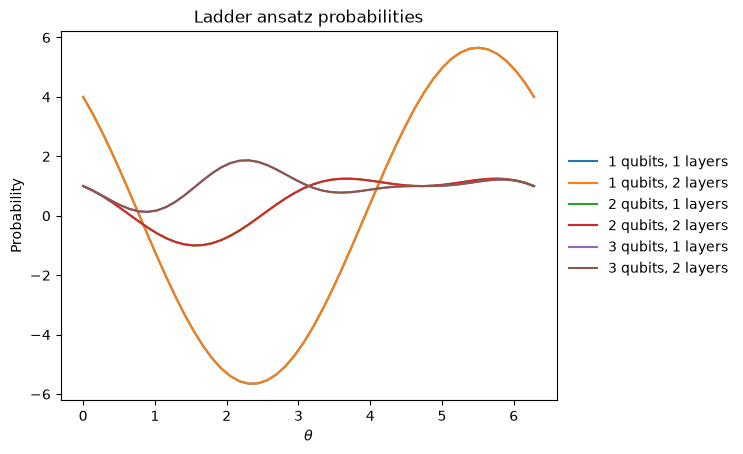

In [127]:
# Ladder ansatz circuit
theta = np.linspace(0, 2 * np.pi, 50)
size = np.arange(1, 4)
layer = np.arange(1, 3)

angles = []
statevectors = []
data = np.zeros((len(size), len(layer), len(theta)))

for i, ss in enumerate(size):
    for j, l in enumerate(layer):
        expected_vals = []
        for angle in theta:
            q = QCircuit(ss)
            for k in range(ss):
                q.rotation(angle, 'y', k)
            q.apply_cnot(0, 1)
            q.apply_cnot(1, 2)
            for k in range(ss):
                q.rotation(angle, 'y', k)
            q.apply_cnot(0, 1)
            q.apply_cnot(1, 2)
            angles.append(angle)
            statevectors.append(q.state)
            ZZ = create_Z_vector(ss)
            prob = np.abs(q.state)
            expected_value = np.conj(ZZ).T @ q.state
            expected_vals.append(float(np.real_if_close(expected_value[0, 0])))
        data[i, j, :] = expected_vals

fig, ax = plt.subplots()
for i, ss in enumerate(size):
    for j, l in enumerate(layer):
        ax.plot(theta, data[i, j, :], label=f"{ss} qubits, {l} layers")

ax.set_xlabel(r'$\theta$')
ax.set_ylabel('Probability')
ax.set_title('Ladder ansatz probabilities')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

print(f"{layer[0]} to {layer[-1]} layers")
print(f"{size[0]} to {size[-1]} sizes")

Text(0, 0.5, 'Density')

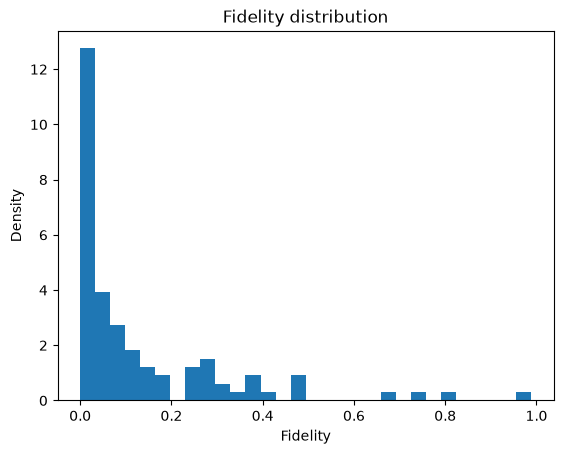

In [128]:

fidelities = []
n = 100
for i in range(n):
    state1 = RandomQCircuit(3, 3)
    state2 = RandomQCircuit(3, 3)
    F = fidelity(state1.state, state2.state)
    fidelities.append(float(np.real_if_close(F)))

fig, ax = plt.subplots()
ax.hist(np.asarray(fidelities).ravel(), bins=30, density=True)
ax.set_title('Fidelity distribution')
ax.set_xlabel('Fidelity')
ax.set_ylabel('Density')